# Apply DyadPredictor to Real Methylation Data

## 1. Imports and setup

In [34]:
import numpy as np
import sys
from pathlib import Path

parent_path = Path.cwd().parent
if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
from scipy.signal import find_peaks
import json

from nuctool.Plotter import Plotter

plot = Plotter()

# Sterachis colormap: white → magenta → blue → cyan → lime → darkgreen
# Intended for nucleosome footprint lengths (0–250 bp)
_sterachis_colors = [
    (0/250,   "white"),
    (45/250,  "yellow"),
    (90/250,  "lime"),
    (135/250,  "limegreen"),
    (170/250,  "cyan"),
    (215/250, "blue"),
    (250/250, "darkblue"),
]
cmap_sterachis = mcolors.LinearSegmentedColormap.from_list(
    "Sterachis", _sterachis_colors, N=250
)
cmap_sterachis.set_bad("white")
cmap_sterachis.set_under("white")

import os
print(os.getcwd())

FIG_SIZE = (15, 4)  # standard figure size: width fixed, height may vary for imshow/tall panels


/home/mvenrooij/NucTool/notebooks


## 2. Configuration

In [35]:
model_filename = rf"data/LLM models/LLM_tests/test_2_15000_fitted_variables.pt"  # dilated model

encoded_path  = "../nuctool/methylation_occupancy/encoded_reads_chrII_273000_283000.npy"
coverage_path = "../nuctool/methylation_occupancy/coverage_chrII_273000_283000.npy"
nuc_occ_path  = "../nuctool/methylation_occupancy/occupancy_locus(chrII:273000-283000).npy"

chrom, start, end = "chrII", 273000, 283000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. Model architecture

In [36]:
class DyadPredictor(nn.Module):
    def __init__(self, vocab_size=8, embedding_dim=16, hidden_dim=64, num_layers=2,
                 dropout=0.3, conv_layers=2, conv_kernel_size=5, conv_dilations=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.conv_layers = conv_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if conv_dilations is None:
            conv_dilations = [1] * conv_layers
        for i in range(conv_layers):
            in_channels = embedding_dim if i == 0 else hidden_dim
            dilation = conv_dilations[i] if i < len(conv_dilations) else 1
            padding = (conv_kernel_size - 1) * dilation // 2
            setattr(self, f"conv{i+1}", nn.Conv1d(in_channels, hidden_dim,
                kernel_size=conv_kernel_size, padding=padding, dilation=dilation))
            setattr(self, f"bn{i+1}", nn.BatchNorm1d(hidden_dim))
        self.lstm = nn.LSTM(hidden_dim, hidden_dim // 2, num_layers=num_layers,
            bidirectional=True, dropout=dropout if num_layers > 1 else 0, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1))

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        for i in range(self.conv_layers):
            x = torch.relu(getattr(self, f"bn{i+1}")(getattr(self, f"conv{i+1}")(x)))
        x = x.transpose(1, 2)
        x, _ = self.lstm(x)
        return self.fc(x)


def predict_dyads(model, encoded_sequence, threshold=0.2, device="cpu"):
    model.eval()
    with torch.no_grad():
        seq_tensor = torch.LongTensor(encoded_sequence).unsqueeze(0).to(device)
        probs = torch.sigmoid(model(seq_tensor)).squeeze().cpu().numpy()
    return np.where(probs >= threshold)[0].tolist(), probs


FOOTPRINT = 147  # nucleosome footprint in bp

def _parabolic_refine(probs, peak_idx):
    """Sub-sample parabolic refinement: returns float offset for each integer peak."""
    refined = np.empty(len(peak_idx), dtype=float)
    for k, p in enumerate(peak_idx):
        if 0 < p < len(probs) - 1:
            y0, y1, y2 = probs[p - 1], probs[p], probs[p + 1]
            denom = y0 - 2 * y1 + y2
            refined[k] = p + np.clip(0.5 * (y0 - y2) / denom, -1.0, 1.0) if denom != 0 else float(p)
        else:
            refined[k] = float(p)
    return refined


def call_dyad_positions(probs, min_spacing=FOOTPRINT, min_height=0.0,
                        min_relative_height=0.5, window=100, genomic_start=0):
    """
    Call dyad positions with parabolic sub-peak refinement.

    After find_peaks identifies integer peak positions, a 3-point parabolic fit
    refines each to a float offset (typically ±0–1 bp). Returned positions are
    rounded to the nearest integer so that downstream array indexing still works.

    Args:
        probs               : np.ndarray (locus_length,) or (n_reads, locus_length)
        min_spacing         : minimum bp between called dyads (default = 147)
        min_height          : absolute minimum probability to be a candidate
        min_relative_height : minimum fraction of local peak area required
        window              : half-width in bp for local peak grouping
        genomic_start       : genomic coordinate of probs[0] (default 0)

    Returns:
        1D input : (positions, scores) — both np.ndarray, positions are int
        2D input : list of (positions, scores) tuples, one per read
    """
    if probs.ndim == 1:
        peak_indices, _ = find_peaks(probs, distance=min_spacing, height=min_height)
        if len(peak_indices) == 0:
            return np.array([], dtype=int) + genomic_start, np.array([])

        # Parabolic refinement → round back to int for array-index compatibility
        refined_float = _parabolic_refine(probs, peak_indices)
        peak_indices  = np.round(refined_float).astype(int).clip(0, len(probs) - 1)
        peak_probs    = probs[peak_indices]

        kept_idx    = []
        kept_scores = []
        for i, idx in enumerate(peak_indices):
            nearby     = np.abs(peak_indices - idx) <= window
            total_area = peak_probs[nearby].sum()
            score      = peak_probs[i] / total_area if total_area > 0 else 0.0
            if score >= min_relative_height:
                kept_idx.append(idx)
                kept_scores.append(score)

        return np.array(kept_idx, dtype=int) + genomic_start, np.array(kept_scores)

    else:
        return [call_dyad_positions(row, min_spacing, min_height,
                                    min_relative_height, window, genomic_start)
                for row in probs]

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(measured, predicted, ax=None, title=None):
    """
    Scatter plot of predicted vs measured values with R² and Pearson r.

    Parameters
    ----------
    measured : array-like
        Observed/experimental occupancy.
    predicted : array-like
        Model output (e.g. from model_func with fitted parameters).
    ax : matplotlib Axes, optional
        Existing axis to draw into. If None, a new figure is created.
    title : str, optional
    """
    measured = np.asarray(measured).ravel()
    predicted = np.asarray(predicted).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Statistics
    r, p_value = pearsonr(measured, predicted)
    r_squared = r ** 2
    rmse = np.sqrt(np.mean((predicted - measured) ** 2))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter
    ax.scatter(measured, predicted, s=8, alpha=0.4, edgecolor='none')

    # y = x reference line
    lo = min(measured.min(), predicted.min())
    hi = max(measured.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')

    # Linear fit line
    slope, intercept = np.polyfit(measured, predicted, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, 'r-', lw=1.2,
            label=f'fit: y = {slope:.2f}x + {intercept:.2f}')

    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.set_title(title or 'Segmented Least Squares Fit correlation')
    ax.set_aspect('equal', adjustable='box')

    # Annotation box with stats
    stats_text = (
        f'$R^2$ = {r_squared:.3f}\n'
        f'r = {r:.3f}\n'
        f'RMSE = {rmse:.4f}\n'
        f'n = {len(measured)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    plt.tight_layout()
    return measured, predicted, slope, intercept, r, r_squared, ax

## 4. Load model

In [38]:
config_path = Path(model_filename).with_suffix(".json")
with open(config_path) as f:
    config = json.load(f)
llm_cfg = config.get("llm", {})

model_params = {
    "vocab_size":      llm_cfg.get("vocab_size", 8),
    "embedding_dim":   llm_cfg.get("embedding_dim", 16),
    "hidden_dim":      llm_cfg.get("hidden_dim", 64),
    "num_layers":      llm_cfg.get("num_layers", 2),
    "dropout":         llm_cfg.get("dropout", 0.3),
    "conv_layers":     llm_cfg.get("conv_layers", 2),
    "conv_kernel_size":llm_cfg.get("conv_kernel_size", 5),
    "conv_dilations":  llm_cfg.get("conv_dilations", None),
}

loaded_model = DyadPredictor(**model_params)
loaded_model.load_state_dict(torch.load(model_filename, map_location=device))
loaded_model = loaded_model.to(device).eval()
print(f"Loaded {model_filename}  ({sum(p.numel() for p in loaded_model.parameters()):,} params)")

Loaded data/LLM models/LLM_tests/test_2_15000_fitted_variables.pt  (680,833 params)


## 5. Load and predict on real reads

In [39]:
encoded_array  = np.load(encoded_path)   # (n_reads, locus_length)
coverage_array = np.load(coverage_path)  # (n_reads, locus_length), bool
nuc_occ        = np.load(nuc_occ_path)
locus_length   = end - start

print(f"Loaded {encoded_array.shape[0]} reads, {locus_length} bp")
print(f"Mean coverage: {coverage_array.mean(axis=0).mean():.1%}")

all_probs = np.zeros((len(encoded_array), locus_length), dtype=np.float32)
for i, encoded in enumerate(tqdm(encoded_array, desc="Predicting dyads")):
    _, all_probs[i] = predict_dyads(loaded_model, encoded, device=device)

n_covering = coverage_array.sum(axis=0).clip(min=1)
mean_probs  = (all_probs * coverage_array).sum(axis=0) / n_covering


Loaded 478 reads, 10000 bp
Mean coverage: 98.5%


Predicting dyads: 100%|██████████| 478/478 [00:16<00:00, 29.62it/s]


## 6. Sort reads by Methylation

In [40]:
# Sort reads by methylation fraction (most → least methylated)
read_lengths  = coverage_array.sum(axis=1)
meth_fraction = ((encoded_array > 3) & coverage_array).sum(axis=1) / read_lengths.clip(min=1)
sort_order    = np.argsort(meth_fraction)[::-1]

encoded_array_f  = encoded_array[sort_order]
coverage_array_f = coverage_array[sort_order]
all_probs_f      = all_probs[sort_order]

print(f"Sorted by methylation: max={meth_fraction[sort_order[0]]:.2%}, "
      f"min={meth_fraction[sort_order[-1]]:.2%}, mean={meth_fraction.mean():.2%}")

Sorted by methylation: max=5.76%, min=0.00%, mean=3.94%


## 7. Mean dyad probability

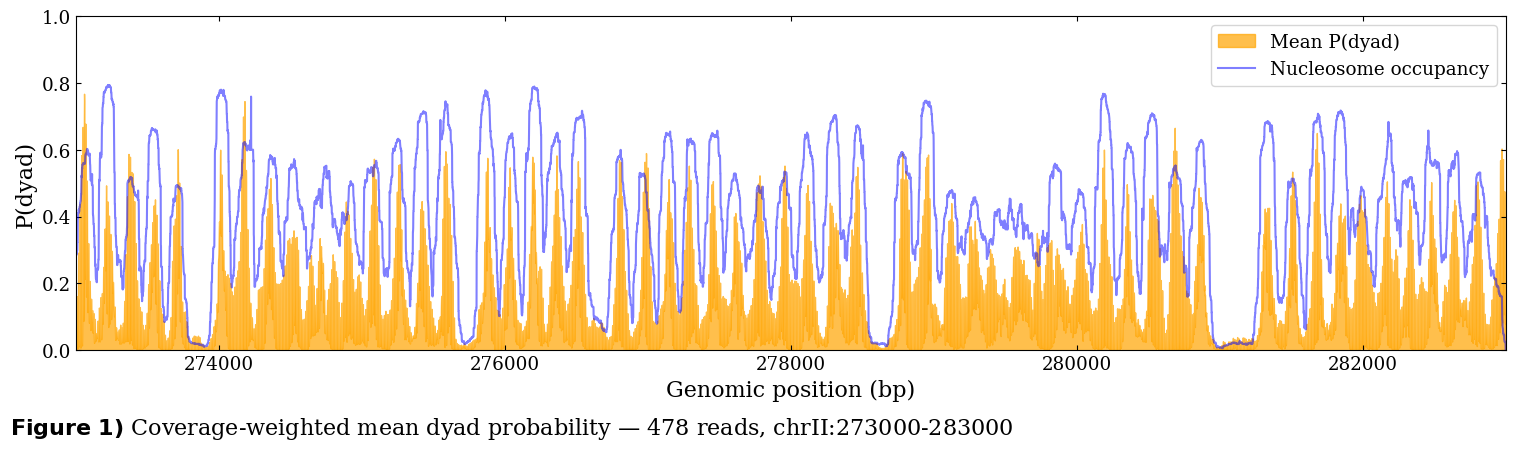

In [41]:
x = np.arange(start, end)

plot.new(fig_size=FIG_SIZE)
plt.fill_between(x, mean_probs, color="orange", alpha=0.7, label="Mean P(dyad)")
plt.plot(x, nuc_occ, color="blue", alpha=0.5, label="Nucleosome occupancy")
plt.xlim(start, end)
plt.ylim(0, 1)
plt.xlabel("Genomic position (bp)")
plt.ylabel("P(dyad)")
plt.legend()
plot.caption(f"Coverage-weighted mean dyad probability — {encoded_array.shape[0]} reads, {chrom}:{start}-{end}")

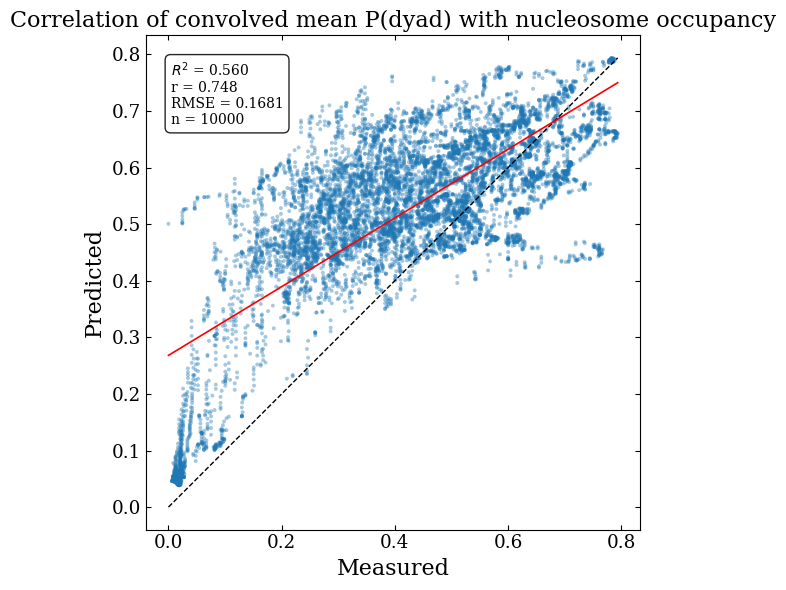

In [42]:
footprint = 147
raw = np.convolve(mean_probs, np.ones(footprint), mode='same')

# Normalise to the same scale as nuc_occ so the shapes are directly comparable
Nuc_mean_occ = raw / raw.max() * nuc_occ.max()

m, p, i, s, r, r2, ax = plot_correlation(nuc_occ, Nuc_mean_occ, title="Correlation of convolved mean P(dyad) with nucleosome occupancy")

xs = np.linspace(0, 1, 100)

/tmp/ipykernel_1306/1536907225.py:39: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax2.plot(xs, i + s * xs, 'r-', lw=1.2, color='red',


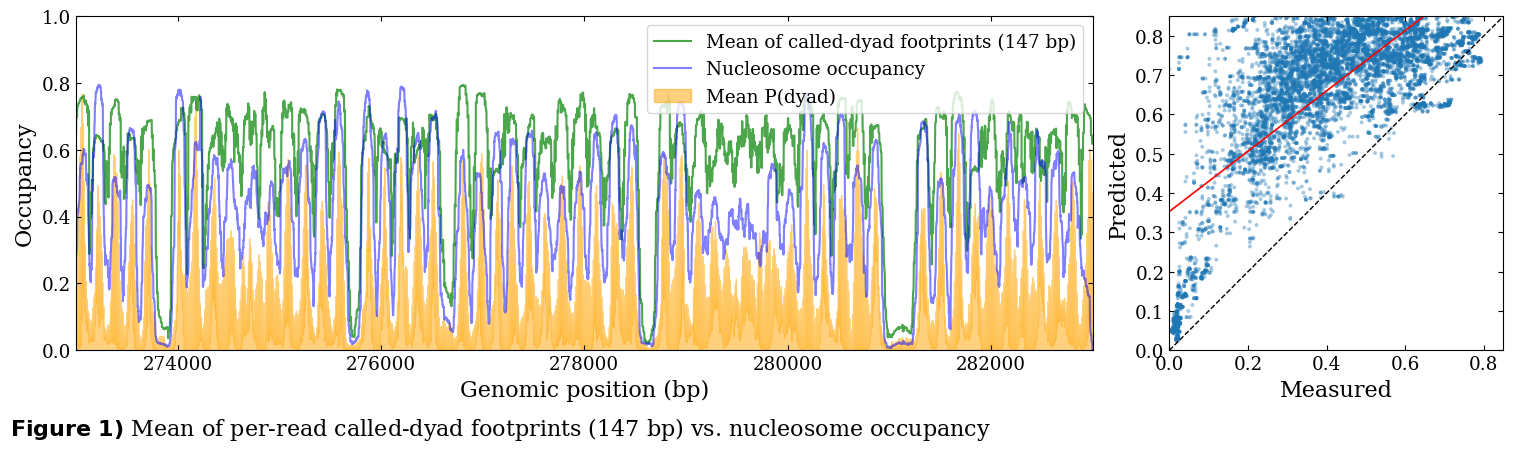

In [43]:
# Call dyads for every read, drop each read's maximum (peak) dyad values onto an
# impulse train, convolve with a 147 bp footprint, then average across reads.
box          = np.ones(FOOTPRINT)
dyad_results = call_dyad_positions(all_probs, min_spacing=FOOTPRINT, min_height=0.0,
                                   min_relative_height=0.5, window=100, genomic_start=0)

conv_matrix = np.zeros_like(all_probs, dtype=float)
for read_i, (dyad_pos, _) in enumerate(dyad_results):
    valid = (dyad_pos >= 0) & (dyad_pos < all_probs.shape[1])
    impulse = np.zeros(all_probs.shape[1])
    impulse[dyad_pos[valid]] = all_probs[read_i, dyad_pos[valid]]   # maximum dyad values
    conv_matrix[read_i] = np.convolve(impulse, box, mode='same')

Nuc_convolve = conv_matrix.mean(axis=0)          # mean over reads

# Correlation of this dyad-based occupancy with the measured nucleosome occupancy
m  = np.asarray(nuc_occ, float).ravel()
p  = Nuc_convolve.ravel()
s, i = np.polyfit(m, p, 1)                        # slope, intercept
r  = float(np.corrcoef(m, p)[0, 1]); r2 = r ** 2
xs = np.linspace(0, 1, 100)


plot = Plotter(fig_size=FIG_SIZE)
plot.new(ncols=2, width_ratios=[3, 1])

ax1, ax2 = plot.axes
ax1.plot(x, (Nuc_convolve*nuc_occ.max())/Nuc_convolve.max(), color="green", alpha=0.7,
         label=f"Mean of called-dyad footprints ({FOOTPRINT} bp)")
ax1.plot(x, nuc_occ, color="blue", alpha=0.5, label="Nucleosome occupancy")
ax1.fill_between(x, mean_probs, color="orange", alpha=0.5, label="Mean P(dyad)")
ax1.set_xlim(start, end)
ax1.set_ylim(0, 1)
ax1.set_xlabel("Genomic position (bp)")
ax1.set_ylabel("Occupancy")
ax1.legend()

ax2.scatter(m, p, s=8, alpha=0.4, edgecolor='none')
ax2.plot(xs, i + s * xs, 'r-', lw=1.2, color='red',
         label=f'Fit: y = {s:.2f}x + {i:.2f}\n$R^2$ = {r2:.3f}\nr = {r:.3f}')
ax2.plot(xs, xs, 'k--', lw=1, label='y = x')
ax2.set_aspect('equal', adjustable='box')
ax2.set_xlim(0, 0.85)
ax2.set_ylim(0, 0.85)
ax2.set_xlabel('Measured')
ax2.set_ylabel('Predicted')

plot.caption("Mean of per-read called-dyad footprints (147 bp) vs. nucleosome occupancy")

## 8. Single-molecule dyad probability map

(478, 10000)


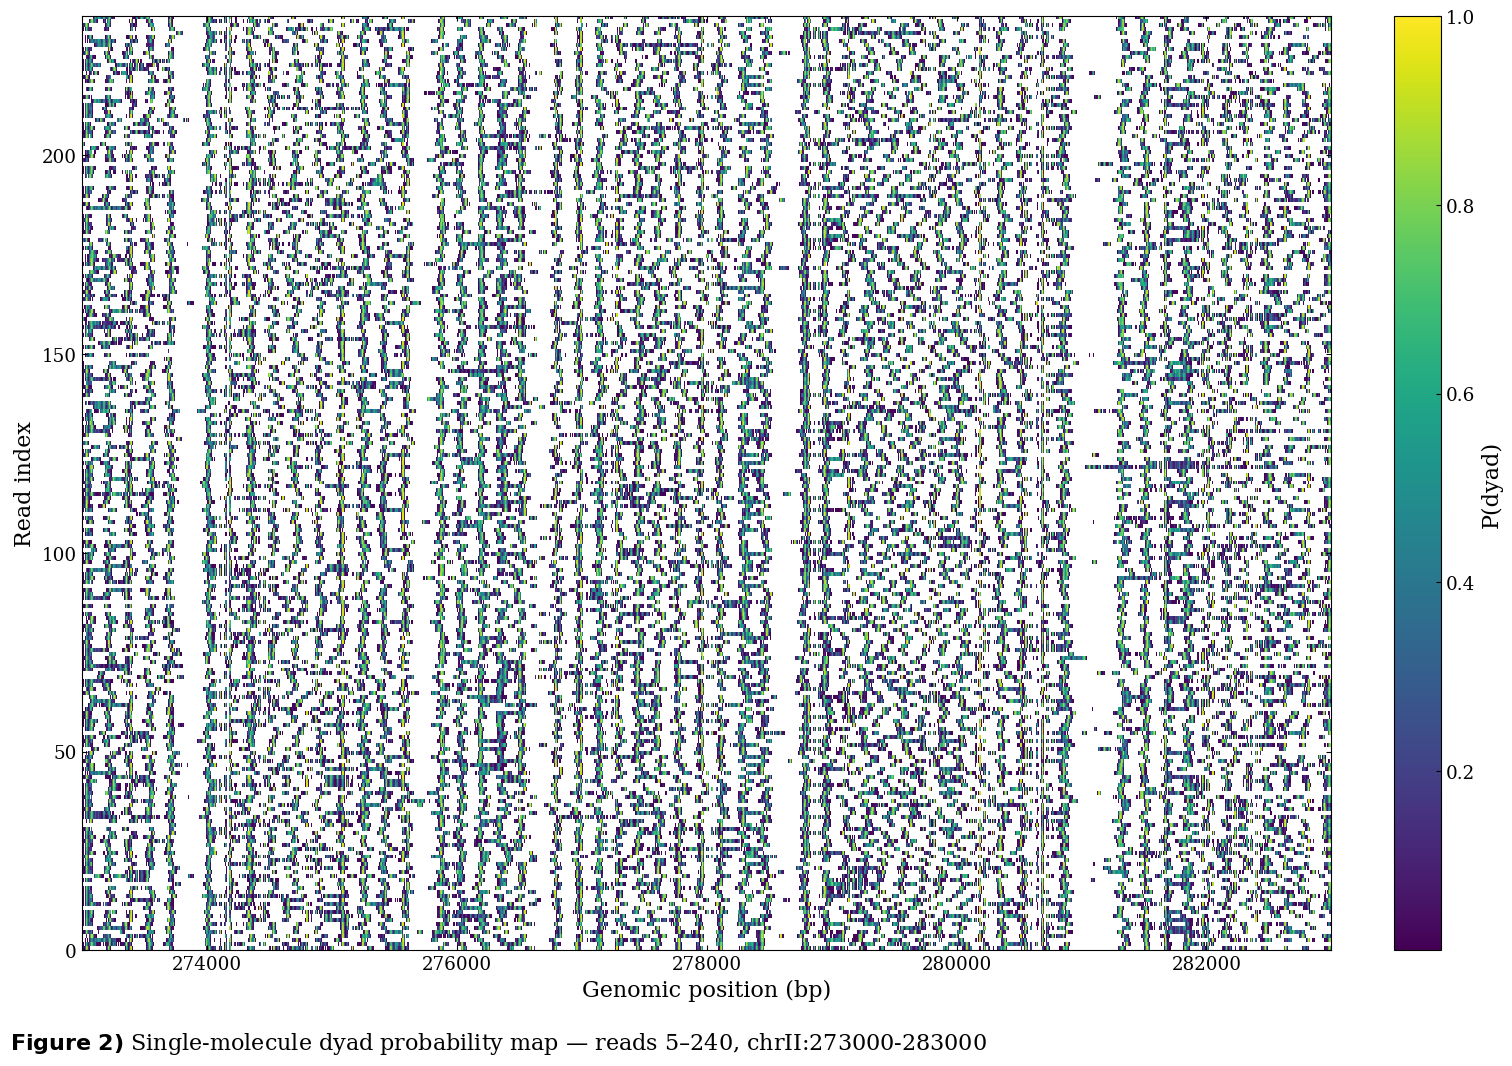

In [44]:
cmap = plt.get_cmap('viridis').copy()
cmap.set_under('white')
cmap.set_bad('white')

read_start, read_end = 5, 240
dyad_matrix = np.where(coverage_array_f, all_probs_f, np.nan)

print(dyad_matrix.shape)

plot.new(fig_size=(FIG_SIZE[0], 10))
plt.imshow(dyad_matrix[read_start:read_end], aspect='auto', cmap=cmap,
           vmin=0.01, vmax=1, interpolation='nearest',
           extent=[start, end, 0, read_end - read_start])
plt.colorbar(label='P(dyad)')
plt.xlabel("Genomic position (bp)")
plt.ylabel("Read index")
plot.caption(f"Single-molecule dyad probability map — reads {read_start}–{read_end}, {chrom}:{start}-{end}")

## 9. Predicted nucleosome locations

In [45]:
def add_row_spacing(matrix, gap=1):
    """Insert `gap` NaN rows between each row of matrix."""
    n_rows, n_cols = matrix.shape
    spacer = np.full((gap, n_cols), np.nan)
    rows = [np.vstack([matrix[i:i+1], spacer]) for i in range(n_rows)]
    return np.vstack(rows)


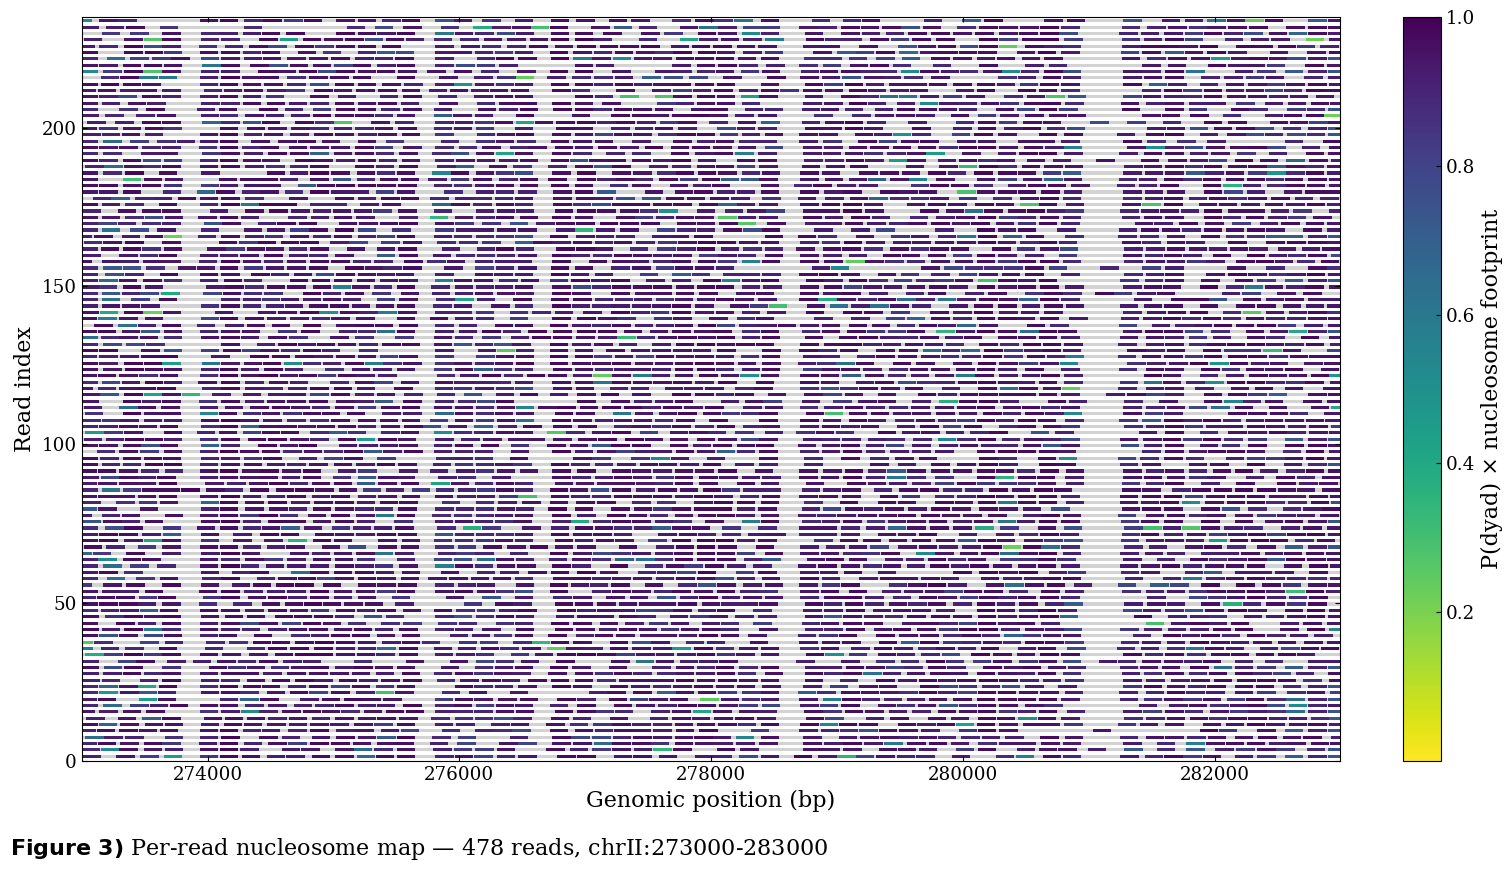

In [46]:
footprint  = 147
half       = footprint // 2
box        = np.ones(footprint)
min_height = 0.2
min_rel    = 0.0

all_dyad_results = call_dyad_positions(
    all_probs_f, min_spacing=footprint, min_height=min_height,
    min_relative_height=min_rel, window=half, genomic_start=0
)

nuc_matrix = np.zeros((len(all_probs_f), locus_length), dtype=np.float32)
for i, (dyad_indices, _) in enumerate(all_dyad_results):
    valid = dyad_indices < locus_length
    dyad_array = np.zeros(locus_length)
    dyad_array[dyad_indices[valid]] = all_probs_f[i, dyad_indices[valid]]
    nuc_matrix[i] = np.convolve(dyad_array, box, mode='same')

spaced_matrix = add_row_spacing(nuc_matrix, gap=1)

cmap_nuc = plt.get_cmap('viridis_r').copy()
cmap_nuc.set_under('lightgray')
cmap_nuc.set_bad('white')

plot.new(fig_size=(FIG_SIZE[0], 8.1))
plt.imshow(spaced_matrix[read_start:read_end], aspect='auto', cmap=cmap_nuc,
           vmin=1e-6, vmax=1, interpolation='nearest',
           extent=[start, end, 0, read_end - read_start])
plt.colorbar(label='P(dyad) × nucleosome footprint')
plt.xlabel("Genomic position (bp)")
plt.ylabel("Read index")
plot.caption(f"Per-read nucleosome map — {len(nuc_matrix)} reads, {chrom}:{start}-{end}")

## 10. Single-read dyad prediction

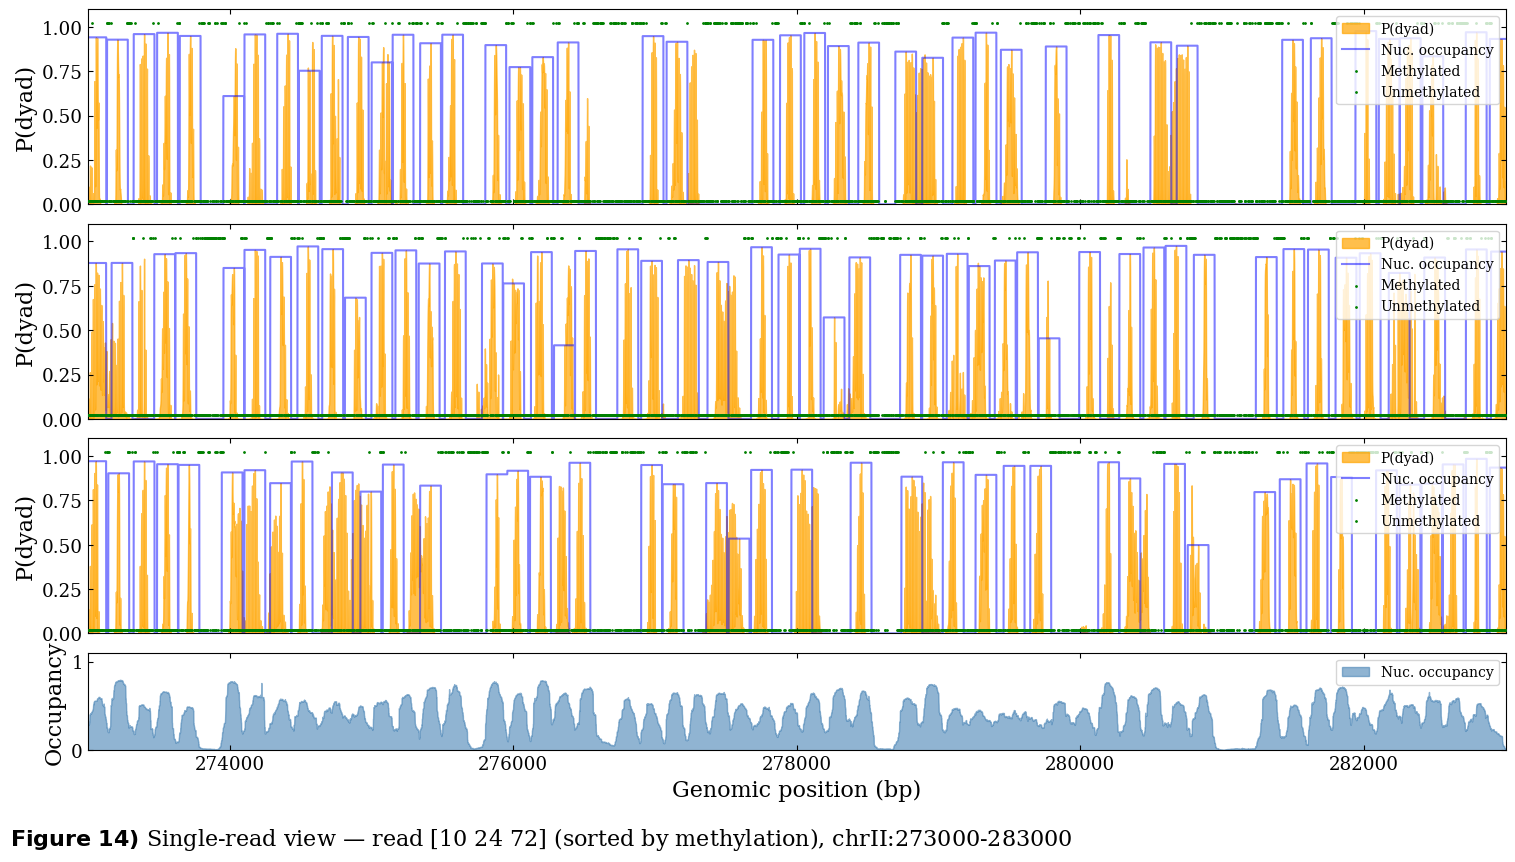

In [78]:
read_idx = np.array([10, 24, 72])  # change to pick a different read

encoded_list = np.zeros((len(encoded_array_f), end - start), dtype=np.int8)
probs_list   = np.zeros((len(encoded_array_f), end - start), dtype=np.float32)
nuc_occ_list = np.zeros((len(encoded_array_f), end - start), dtype=np.float32)
dyad_pos_list = np.zeros((len(encoded_array_f),), dtype=np.int32)

x = np.arange(start, end)

methylated_mask_list = np.zeros((len(encoded_array_f), end - start), dtype=bool)
unmethylated_mask_list = np.zeros((len(encoded_array_f), end - start), dtype=bool)
for i, read_id in enumerate(read_idx):
    encoded_list[i] = encoded_array_f[read_id]
    probs_list[i]   = all_probs_f[read_id]
    nuc_occ_list[i] = nuc_matrix[read_id]
    # dyad_pos_list[i] = all_dyad_results[read_id][0]

    methylated_mask_list[i] = (encoded_array_f[read_id] == 4) | (encoded_array_f[read_id] == 7)
    unmethylated_mask_list[i] = (encoded_array_f[read_id] == 0) if (encoded_array_f[read_id] == 4).any() else np.zeros_like(encoded_array_f[read_id], dtype=bool)
    unmethylated_mask_list[i] = (encoded_array_f[read_id] == 3) if (encoded_array_f[read_id] == 3).any() else unmethylated_mask_list[i]


plot.new(fig_size=(FIG_SIZE[0], 8), nrows=4, sharex=True, height_ratios=[2, 2, 2, 1])
axes = plot.axes

for i in range(len(read_idx)):
    # --- top panel: dyad probability + called dyads ---
    axes[i].fill_between(x, probs_list[i], color="orange", alpha=0.7, label="P(dyad)")
    # ax_top.vlines(dyad_pos+start, ymin=0, ymax=1, color="cyan", linewidth=1.0,
    #               alpha=0.9, label="Called dyads")
    axes[i].plot(x, nuc_occ_list[i], color="blue", alpha=0.5, label="Nuc. occupancy")
    axes[i].scatter(x[methylated_mask_list[i]],
                    np.ones(methylated_mask_list[i].sum()) * 1.02,
                    color="green", s=1, zorder=3, label="Methylated")
    axes[i].scatter(x[unmethylated_mask_list[i]],
                    np.ones(unmethylated_mask_list[i].sum()) * 0.02,
                    color="green", s=1, zorder=3, label="Unmethylated")
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel("P(dyad)")
    axes[i].legend(loc="upper right", fontsize=10)

# --- bottom panel: nucleosome occupancy ---
axes[-1].fill_between(x, nuc_occ, color="steelblue", alpha=0.6, label="Nuc. occupancy")
axes[-1].set_ylim(0, 1.1)
axes[-1].set_ylabel("Occupancy")
axes[-1].set_xlabel("Genomic position (bp)")
axes[-1].legend(loc="upper right", fontsize=10)

axes[0].set_xlim(start, end)
plot.caption(f"Single-read view — read {read_idx} (sorted by methylation), {chrom}:{start}-{end}")

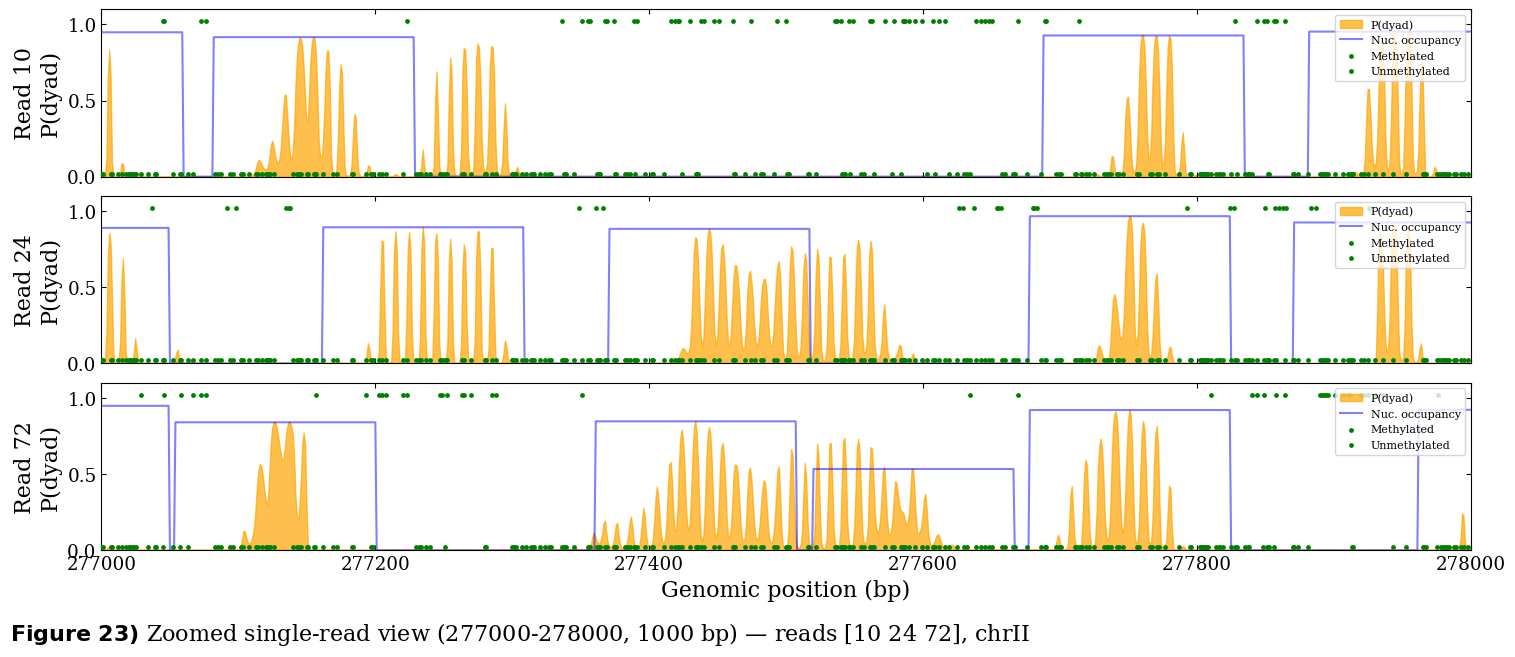

In [87]:
# Zoomed-in view: 1000 bp window (277000-278000), all 3 reads stacked
# Reuses probs_list / nuc_occ_list / methylation masks from the cell above.
zoom_start, zoom_end = 277000, 278000

plot.new(fig_size=(FIG_SIZE[0], 6), nrows=len(read_idx), sharex=True)
axes_z = plot.axes

for i in range(len(read_idx)):
    axes_z[i].fill_between(x, probs_list[i], color="orange", alpha=0.7, label="P(dyad)")
    axes_z[i].plot(x, nuc_occ_list[i], color="blue", alpha=0.5, label="Nuc. occupancy")

    # methylation calls restricted to the zoom window
    win = (x >= zoom_start) & (x < zoom_end)
    m = methylated_mask_list[i]   & win
    u = unmethylated_mask_list[i] & win
    axes_z[i].scatter(x[m], np.full(m.sum(), 1.02), color="green", s=6, zorder=3, label="Methylated")
    axes_z[i].scatter(x[u], np.full(u.sum(), 0.02), color="green", s=6, zorder=3, label="Unmethylated")

    axes_z[i].set_ylim(0, 1.1)
    axes_z[i].set_ylabel(f"Read {read_idx[i]}\nP(dyad)")
    axes_z[i].legend(loc="upper right", fontsize=8)

axes_z[-1].set_xlim(zoom_start, zoom_end)
axes_z[-1].set_xlabel("Genomic position (bp)")
plot.caption(
    f"Zoomed single-read view ({zoom_start}-{zoom_end}, {zoom_end - zoom_start} bp) — "
    f"reads {read_idx}, {chrom}"
)


55/55 consensus peaks fitted — confidence mean 0.11, median 0.11


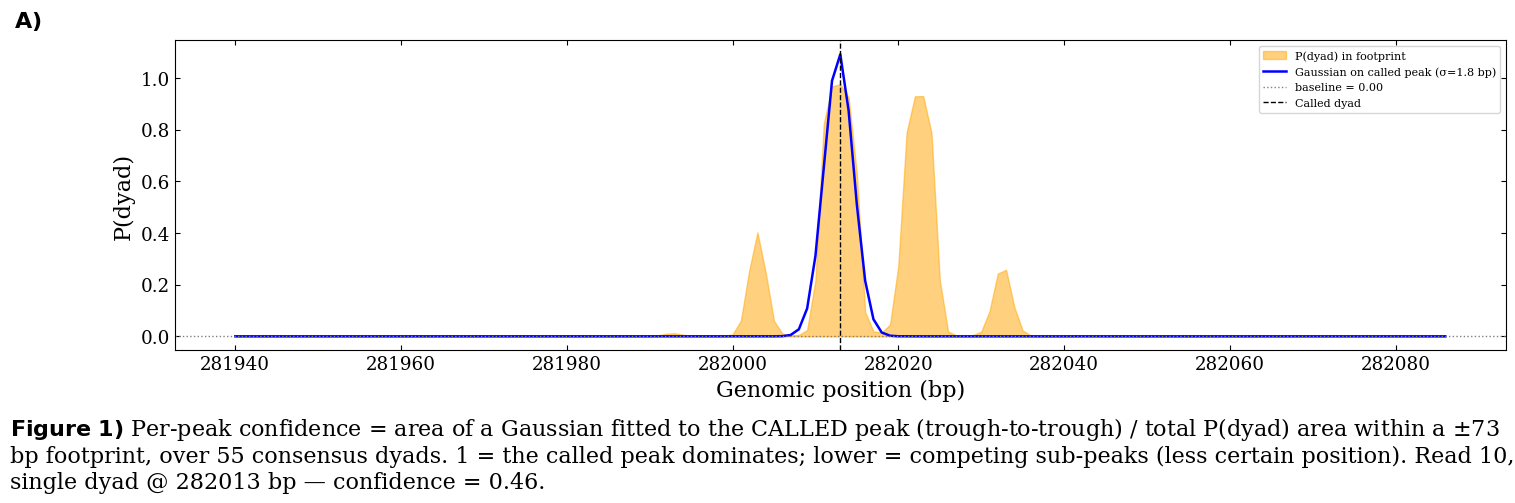

In [ ]:
# ── Per-peak confidence: Gaussian on the CALLED peak / total footprint area ──
# The footprint often contains several competing sub-peaks (rotational positions
# ~10 bp apart). We isolate the single called peak (trough-to-trough), fit
# base + amp·exp(-½((x-µ)/σ)²) to *that* peak only, and divide its area by the
# total P(dyad) area in the ±footprint/2 window.
#   ~1  -> the called peak owns nearly all the local mass  (dominant, confident)
#   <1  -> other sub-peaks share the mass                  (ambiguous position)
from scipy.optimize import curve_fit

# numpy>=2.0 renamed np.trapz -> np.trapezoid
_trapz = getattr(np, 'trapezoid', getattr(np, 'trapz', None))

def _gauss_base(x, amp, mu, sigma, base):
    return base + amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def _isolate_peak(probs, p, lo, hi):
    """Nearest local minima bracketing the peak at index p (single-peak support)."""
    l = p
    while l - 1 >= lo and probs[l - 1] < probs[l]:
        l -= 1
    r = p
    while r + 1 < hi and probs[r + 1] < probs[r]:
        r += 1
    return l, r

def peak_confidence(probs, peak_idx, footprint=147, return_fit=False):
    half   = footprint // 2
    p      = int(round(peak_idx))
    lo, hi = max(0, p - half), min(len(probs), p + half + 1)
    total_area = _trapz(np.asarray(probs[lo:hi], float), np.arange(lo, hi))
    if total_area <= 1e-9:
        return (np.nan, None) if return_fit else np.nan

    l, r = _isolate_peak(probs, p, lo, hi)          # bracket the called peak only
    xp = np.arange(l, r + 1)
    yp = np.asarray(probs[l:r + 1], dtype=float)
    if len(xp) < 4:                                 # too few points to fit a Gaussian
        gauss_area = _trapz(yp - yp.min(), xp) if len(xp) >= 2 else 0.0
        ratio = gauss_area / total_area
        return (ratio, None) if return_fit else ratio
    try:
        popt, _ = curve_fit(
            _gauss_base, xp, yp,
            p0=[yp.max() - yp.min(), p, 3.0, 0],
            bounds=([0.0, l, 0.5, 0.0], [1.5, r, max(r - l, 1.0), max(yp.max(), 1e-3)]),
            maxfev=5000,
        )
    except (RuntimeError, ValueError):
        return (np.nan, None) if return_fit else np.nan
    amp, mu, sigma, base = popt
    gauss_area = amp * sigma * np.sqrt(2 * np.pi)   # analytic area of the single-peak Gaussian
    ratio = gauss_area / total_area
    return (ratio, (popt, lo, hi)) if return_fit else ratio

# Score the consensus dyads on the smooth coverage-weighted mean profile
cons_pos, _ = call_dyad_positions(mean_probs, min_spacing=footprint, min_height=0.1,
                                  min_relative_height=0.0, window=footprint // 2)
conf = np.array([peak_confidence(mean_probs, p, footprint) for p in cons_pos])
ok   = ~np.isnan(conf)
print(f"{ok.sum()}/{len(cons_pos)} consensus peaks fitted — "
      f"confidence mean {np.nanmean(conf):.2f}, median {np.nanmedian(conf):.2f}")

# Example: a SINGLE called dyad on a SINGLE read
med = np.nanmedian(conf)                           # (used by the histogram panel)
read_id = 10                                      # read to illustrate

ex = ratio_ex = fit_ex = probs_read = None
for ri in [read_id, *range(len(all_probs_f))]:    # requested read first, then any other
    pr = all_probs_f[ri]
    dyads_ri, _ = call_dyad_positions(pr, min_spacing=footprint, min_height=0.2,
                                      min_relative_height=0.0, window=footprint // 2)
    if len(dyads_ri) == 0:
        continue
    for d in dyads_ri[np.argsort(pr[dyads_ri])[::-1]]:   # try the strongest calls first
        r, f = peak_confidence(pr, int(d), footprint, return_fit=True)
        if f is not None:
            read_id, probs_read, ex, ratio_ex, fit_ex = ri, pr, int(d), r, f
            break
    if fit_ex is not None:
        break

popt_ex, lo_ex, hi_ex = fit_ex
xw = np.arange(lo_ex, hi_ex)

plot = Plotter(fig_size=FIG_SIZE)
plot.new(ncols=1)
axA = plot.axes

axA.fill_between(xw + start, probs_read[lo_ex:hi_ex], color='orange', alpha=0.5,
                 label='P(dyad) in footprint')
axA.plot(xw + start, _gauss_base(xw, *popt_ex), 'b-', lw=1.8,
         label=f'Gaussian on called peak (σ={popt_ex[2]:.1f} bp)')
axA.axhline(popt_ex[3], color='grey', ls=':', lw=1, label=f'baseline = {popt_ex[3]:.2f}')
axA.axvline(ex + start, color='k', ls='--', lw=1, label='Called dyad')
axA.set_xlabel("Genomic position (bp)")
axA.set_ylabel("P(dyad)")
axA.set_title(f"Read {read_id}, single dyad @ {ex + start} bp — confidence = {ratio_ex:.2f}")
axA.legend(fontsize=8)


plot.caption(
    f"Per-peak confidence = area of a Gaussian fitted to the CALLED peak (trough-to-trough) / "
    f"total P(dyad) area within a \u00b1{footprint // 2} bp footprint."
)


In [ ]:
# ── Per-read nucleosome map coloured by peak confidence ─────────────────────
# Same layout as the P(dyad)×footprint map above, but each nucleosome footprint
# is coloured by peak_confidence of its called dyad (Gaussian-peak area / total
# footprint area). Note: per-read tracks are noisier than the mean, so this runs
# a curve fit per called dyad (~tens of thousands) and takes a little while.
conf_matrix = np.zeros((len(all_probs_f), locus_length), dtype=np.float32)
for i, (dyad_indices, _) in enumerate(tqdm(all_dyad_results, desc="Scoring dyad confidence")):
    for d in dyad_indices:
        if d >= locus_length:
            continue
        c = peak_confidence(all_probs_f[i], d, footprint)
        if np.isnan(c):
            continue
        lo = max(0, d - half)
        hi = min(locus_length, d + half + 1)
        conf_matrix[i, lo:hi] = np.maximum(conf_matrix[i, lo:hi], c)

spaced_conf = add_row_spacing(conf_matrix, gap=1)

Scoring dyad confidence: 100%|██████████| 478/478 [01:02<00:00,  7.67it/s]


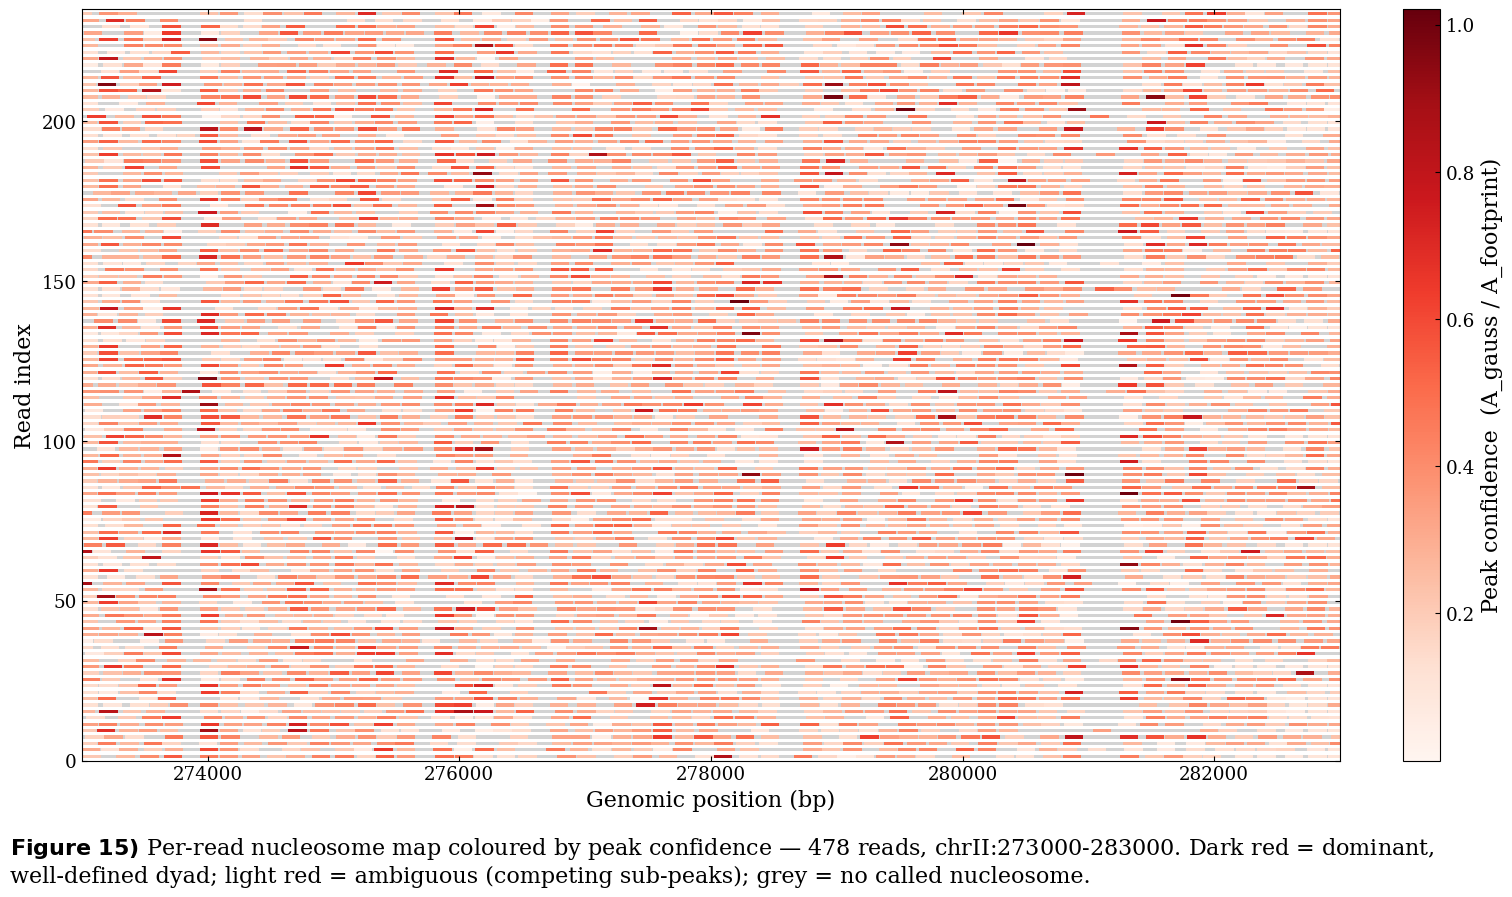

In [79]:
from matplotlib.colors import LinearSegmentedColormap
cmap_conf = LinearSegmentedColormap.from_list('light_to_dark_red',
    ['#fff5f0', '#fee0d2', '#fcbba1', '#fc9272', '#fb6a4a', '#ef3b2c', '#cb181d', '#a50f15', '#67000d'])
cmap_conf.set_under('lightgray')     # positions with no called nucleosome
cmap_conf.set_bad('white')           # row-spacing gaps

plot.new(fig_size=(FIG_SIZE[0], 8.1))
plt.imshow(spaced_conf[read_start:read_end], aspect='auto', cmap=cmap_conf,
           vmin=1e-6, vmax=np.nanmax(conf_matrix), interpolation='nearest',
           extent=[start, end, 0, read_end - read_start])
plt.colorbar(label='Peak confidence  (A_gauss / A_footprint)')
plt.xlabel("Genomic position (bp)")
plt.ylabel("Read index")
plot.caption(
    f"Per-read nucleosome map coloured by peak confidence — {len(conf_matrix)} reads, "
    f"{chrom}:{start}-{end}. Dark red = dominant, well-defined dyad; "
    "light red = ambiguous (competing sub-peaks); grey = no called nucleosome."
)


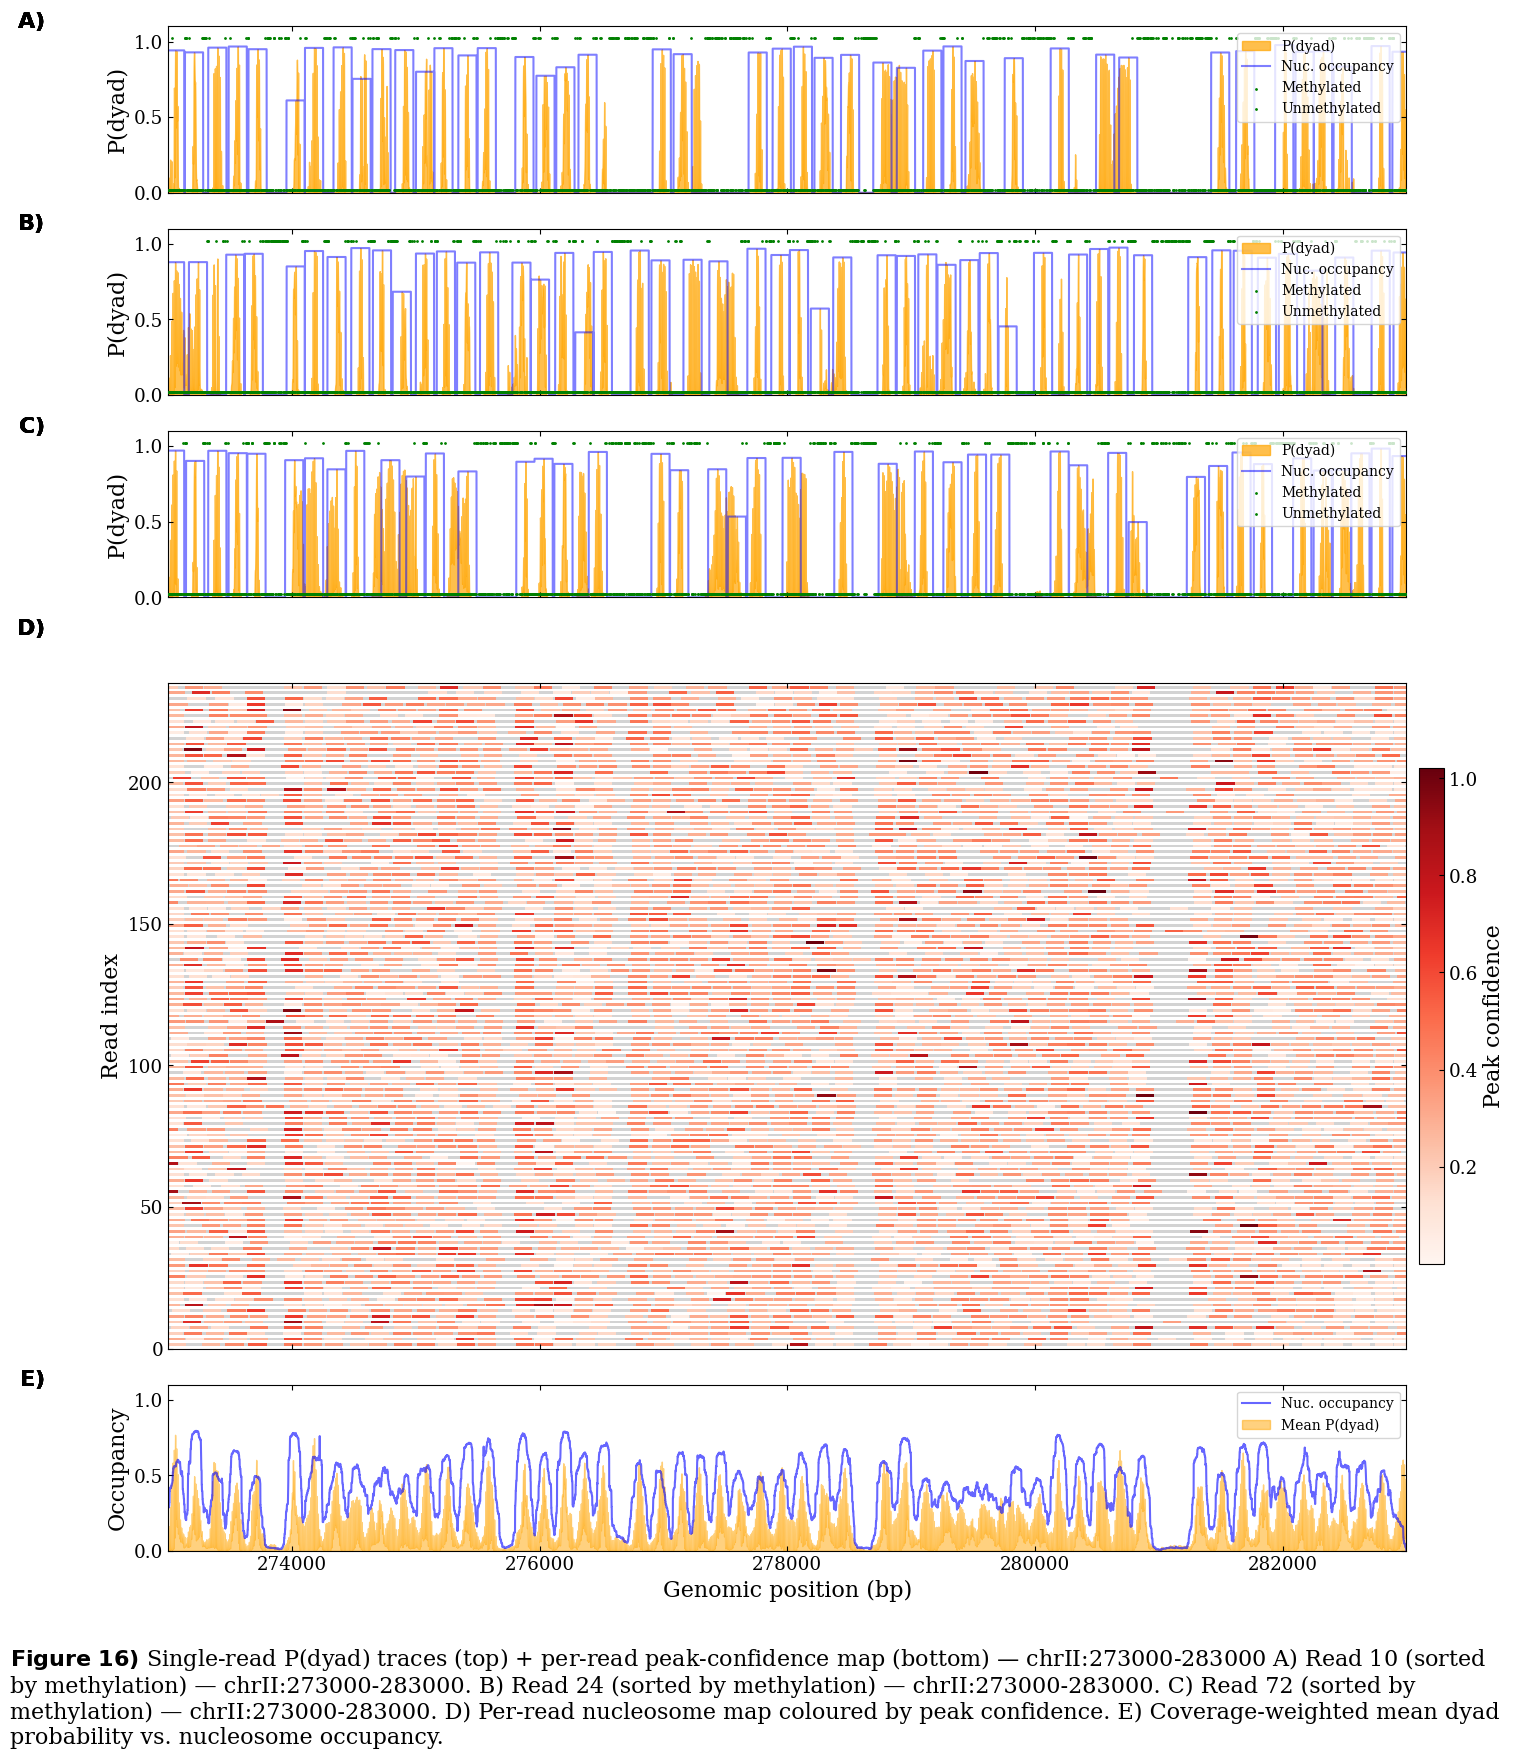

In [80]:
plot.new(fig_size=(FIG_SIZE[0], 16), nrows=5, sharex=True, height_ratios=[2, 2, 2, 8, 2])
axes = plot.axes

for i in range(len(read_idx)):
    # --- top panel: dyad probability + called dyads ---
    axes[i].fill_between(x, probs_list[i], color="orange", alpha=0.7, label="P(dyad)")
    # ax_top.vlines(dyad_pos+start, ymin=0, ymax=1, color="cyan", linewidth=1.0,
    #               alpha=0.9, label="Called dyads")
    axes[i].plot(x, nuc_occ_list[i], color="blue", alpha=0.5, label="Nuc. occupancy")
    axes[i].scatter(x[methylated_mask_list[i]],
                    np.ones(methylated_mask_list[i].sum()) * 1.02,
                    color="green", s=1, zorder=3, label="Methylated")
    axes[i].scatter(x[unmethylated_mask_list[i]],
                    np.ones(unmethylated_mask_list[i].sum()) * 0.02,
                    color="green", s=1, zorder=3, label="Unmethylated")
    axes[i].set_ylim(0, 1.1)
    axes[i].set_ylabel("P(dyad)")
    axes[i].legend(loc="upper right", fontsize=10)
    axes[i].set_title(f"Read {read_idx[i]} (sorted by methylation) — {chrom}:{start}-{end}")

# --- bottom panel: per-read nucleosome map coloured by peak confidence ---
im = axes[-2].imshow(spaced_conf[read_start:read_end], aspect='auto', cmap=cmap_conf,
                     vmin=1e-6, vmax=np.nanmax(conf_matrix), interpolation='nearest',
                     extent=[start, end, 0, read_end - read_start])
axes[-2].set_ylabel("Read index")
axes[-2].set_title("Per-read nucleosome map coloured by peak confidence")
# colorbar drawn from all axes so the shared x-axis stays aligned across panels
plt.colorbar(im, ax=axes[-2], label='Peak confidence', fraction=0.02, pad=0.01)
axes[-1].plot(x, nuc_occ, color="blue", alpha=0.6, label="Nuc. occupancy")
axes[-1].fill_between(x, mean_probs, color="orange", alpha=0.5, label="Mean P(dyad)")
axes[-1].set_xlim(start, end)
axes[-1].set_ylim(0, 1.1)
axes[-1].legend(loc="upper right", fontsize=10)
axes[-1].set_xlabel("Genomic position (bp)")
axes[-1].set_ylabel("Occupancy")
axes[-1].set_title("Coverage-weighted mean dyad probability vs. nucleosome occupancy")
plot.caption(f"Single-read P(dyad) traces (top) + per-read peak-confidence map (bottom) — {chrom}:{start}-{end}")

## 12. Dyad spacing distribution

Total inter-dyad spacings: 23803
Mean: 198.6 bp,  Median: 173.0 bp,  Std: 67.9 bp


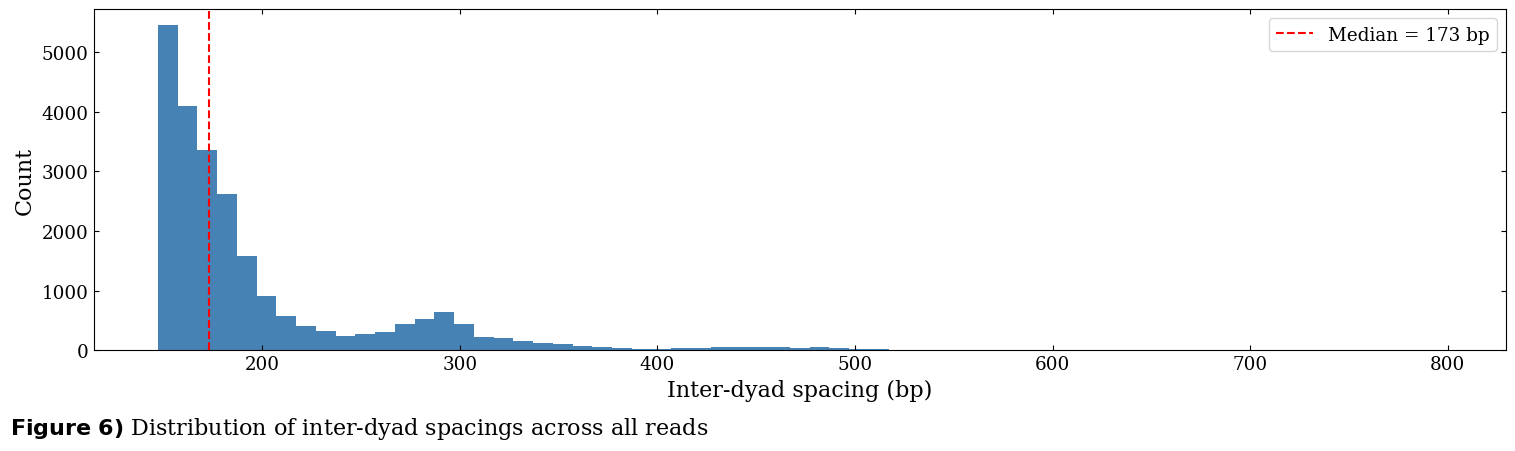

In [ ]:
# --- Analysis 1: inter-dyad spacing ---
# Call dyads for all reads and collect consecutive spacings.
# Expected nucleosome repeat length (NRL) in yeast is ~165 bp.

all_dyad_results = call_dyad_positions(
    all_probs_f, min_spacing=FOOTPRINT, min_height=0.2,
    min_relative_height=0.5, window=100, genomic_start=0
)

spacings = []
for dyad_pos, _ in all_dyad_results:
    if len(dyad_pos) >= 2:
        spacings.extend(np.diff(np.sort(dyad_pos)).tolist())

spacings = np.array(spacings)
print(f"Total inter-dyad spacings: {len(spacings)}")
print(f"Mean: {spacings.mean():.1f} bp,  Median: {np.median(spacings):.1f} bp,  Std: {spacings.std():.1f} bp")

plot.new(fig_size=FIG_SIZE)
plt.hist(spacings, bins=np.arange(FOOTPRINT, 800, 10), color='steelblue', edgecolor='none')
plt.axvline(np.median(spacings), color='red', linestyle='--', lw=1.5,
            label=f'Median = {np.median(spacings):.0f} bp')
plt.xlabel("Inter-dyad spacing (bp)")
plt.ylabel("Count")
plt.legend()
plot.caption("Distribution of inter-dyad spacings across all reads")

## 14. Methylation vs sequence contribution

Running model (with meth vs seq only): 100%|██████████| 100/100 [00:08<00:00, 11.84it/s]


Correlation between meth and seq-only predictions: r = 0.4566
Mean |delta| = 0.13580


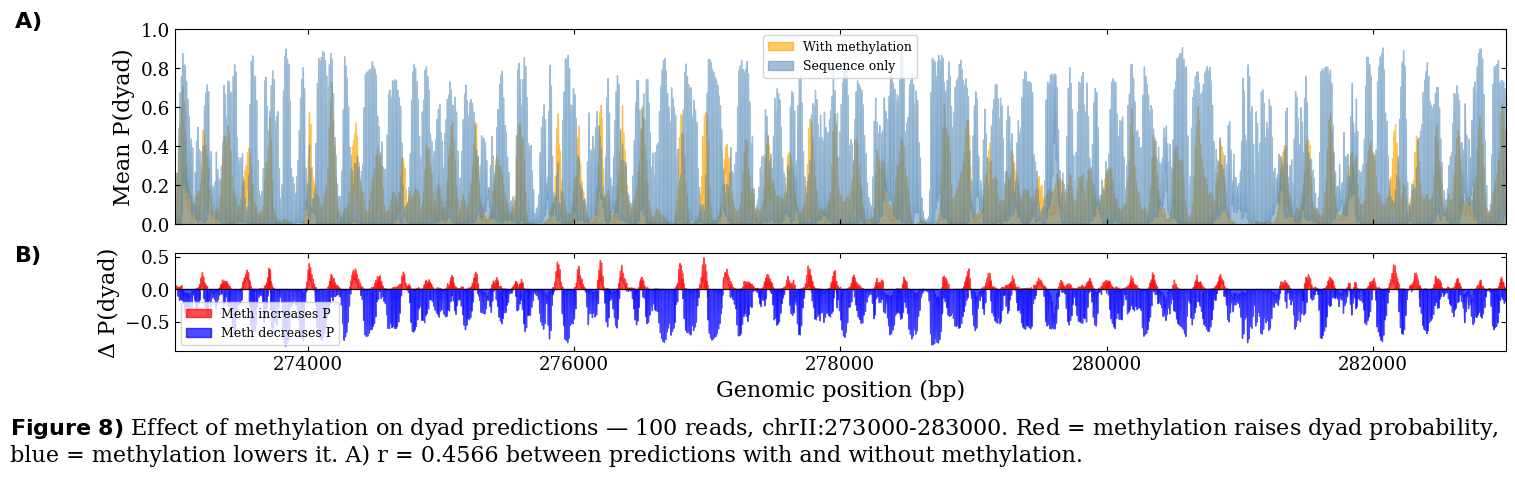

In [ ]:
# --- Analysis 3: methylation vs sequence contribution ---
# Run the model twice per read:
#   (a) original encoding (values 0-7, methylation present)
#   (b) sequence-only   (values 4-7 mapped to 0-3 → methylation stripped)
# The difference in predictions shows where methylation matters.

n_sample = min(100, len(encoded_array_f))   # use subset for speed

probs_with_meth = np.zeros((n_sample, locus_length), dtype=np.float32)
probs_seq_only  = np.zeros((n_sample, locus_length), dtype=np.float32)

for i in tqdm(range(n_sample), desc="Running model (with meth vs seq only)"):
    enc     = encoded_array_f[i]
    enc_seq = enc.copy()
    enc_seq[enc_seq > 3] -= 4   # strip methylation: a→A, c→C, g→G, t→T

    _, probs_with_meth[i] = predict_dyads(loaded_model, enc,     device=device)
    _, probs_seq_only[i]  = predict_dyads(loaded_model, enc_seq, device=device)

delta = probs_with_meth - probs_seq_only   # positive = meth increases dyad prob

x = np.arange(start, end)
mean_with = probs_with_meth.mean(axis=0)
mean_seq  = probs_seq_only.mean(axis=0)
mean_delta = delta.mean(axis=0)

# Pearson correlation between the two mean profiles
from scipy.stats import pearsonr
r, _ = pearsonr(mean_with, mean_seq)
print(f"Correlation between meth and seq-only predictions: r = {r:.4f}")
print(f"Mean |delta| = {np.abs(mean_delta).mean():.5f}")

plot.new(fig_size=FIG_SIZE, nrows=2, sharex=True, height_ratios=[2, 1])
ax1, ax2 = plot.axes

ax1.fill_between(x, mean_with, color='orange', alpha=0.6, label='With methylation')
ax1.fill_between(x, mean_seq,  color='steelblue', alpha=0.5, label='Sequence only')
ax1.set_ylim(0, 1); ax1.set_ylabel("Mean P(dyad)")
ax1.legend(fontsize=9)
ax1.set_title(f"r = {r:.4f} between predictions with and without methylation")

ax2.fill_between(x, mean_delta, where=mean_delta > 0, color='red',   alpha=0.7, label='Meth increases P')
ax2.fill_between(x, mean_delta, where=mean_delta < 0, color='blue',  alpha=0.7, label='Meth decreases P')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel("Δ P(dyad)")
ax2.set_xlabel("Genomic position (bp)")
ax2.legend(fontsize=9)

ax1.set_xlim(start, end)
plot.caption(f"Effect of methylation on dyad predictions — {n_sample} reads, {chrom}:{start}-{end}. "
             f"Red = methylation raises dyad probability, blue = methylation lowers it.")